In [2]:
import requests
from bs4 import BeautifulSoup
import re
import time
import spacy

In [3]:
def get_urls_from_file(filename):
    urls = []
    with open(filename, 'r', encoding='utf-8') as file:
        for line in file:
            match = re.search(r'(https?://\S+)', line)
            if match:
                urls.append(match.group(1))

    return urls

In [17]:
pl_urls = get_urls_from_file('pl.txt')
en_urls = get_urls_from_file('en.txt')

In [5]:
def fetch_wikipedia_text(url):
    headers = {
        'User-Agent': 'ProjektAnalizyTekstuNLP/1.0 (kontakt_testowy@example.com)'
    }
    
    response = requests.get(url, headers=headers)
    response.raise_for_status() 
    
    soup = BeautifulSoup(response.text, 'html.parser')
    paragraphs = soup.find_all('p')
    
    text = ' '.join([p.get_text().strip() for p in paragraphs])
    return text

In [18]:
pl_corpus_raw = []

for i, url in enumerate(pl_urls):
    print(f"Pobieranie ({i+1}/{len(pl_urls)}): {url}")
    
    try:
        text = fetch_wikipedia_text(url)
        pl_corpus_raw.append(text)
    except Exception as e:
        print(f" -> Błąd pobierania: {e}")
    
    if i < len(pl_urls) - 1:
        time.sleep(5)

en_corpus_raw = []

for i, url in enumerate(en_urls):
    print(f"Pobieranie ({i+1}/{len(en_urls)}): {url}")
    
    try:
        text = fetch_wikipedia_text(url)
        en_corpus_raw.append(text)
    except Exception as e:
        print(f" -> Błąd pobierania: {e}")
    
    if i < len(en_urls) - 1:
        time.sleep(5)


Pobieranie (1/8): https://pl.wikipedia.org/wiki/Jagiellonia_Bia%C5%82ystok
Pobieranie (2/8): https://pl.wikipedia.org/wiki/Jes%C3%BAs_Imaz
Pobieranie (3/8): https://pl.wikipedia.org/wiki/Stadion_Miejski_w_Bia%C5%82ymstoku
Pobieranie (4/8): https://pl.wikipedia.org/wiki/S%C5%82awomir_Abramowicz
Pobieranie (5/8): https://pl.wikipedia.org/wiki/Bart%C5%82omiej_Wdowik
Pobieranie (6/8): https://pl.wikipedia.org/wiki/Taras_Romanczuk
Pobieranie (7/8): https://pl.wikipedia.org/wiki/Afimico_Pululu
Pobieranie (8/8): https://pl.wikipedia.org/wiki/Adrian_Siemieniec
Pobieranie (1/8): https://en.wikipedia.org/wiki/Jagiellonia_Bia%C5%82ystok
Pobieranie (2/8): https://en.wikipedia.org/wiki/Jes%C3%BAs_Imaz
Pobieranie (3/8): https://en.wikipedia.org/wiki/Stadion_Miejski_(Bia%C5%82ystok)
Pobieranie (4/8): https://en.wikipedia.org/wiki/S%C5%82awomir_Abramowicz
Pobieranie (5/8): https://en.wikipedia.org/wiki/Bart%C5%82omiej_Wdowik
Pobieranie (6/8): https://en.wikipedia.org/wiki/Taras_Romanczuk
Pobieranie (7

In [20]:
nlp_pl = spacy.load("pl_core_news_sm", disable=['ner', 'parser'])
nlp_en = spacy.load("en_core_web_sm", disable=['ner', 'parser'])

In [43]:
def preprocess_text(text, nlp_model, lang='pl'):
    custom_stopwords = {'jagielloć', 'jagielloni', 'jagiellonię'}
    
    if lang == 'pl':
        text_cleaned = re.sub(r'[^a-zA-ZąćęłńóśźżĄĆĘŁŃÓŚŹŻ]', ' ', text)
    else: 
        text_cleaned = re.sub(r'[^a-zA-Z]', ' ', text)
    
    doc = nlp_model(text_cleaned.lower())

    processed_tokens = []

    for token in doc:
        if (not token.is_stop and 
            not token.is_space and 
            len(token.text) > 1 and 
            token.lemma_ not in custom_stopwords):
            processed_tokens.append(token.lemma_)
        
    return processed_tokens

In [44]:
pl_corpus_processed = [preprocess_text(text, nlp_pl, lang='pl') for text in pl_corpus_raw]
en_corpus_processed = [preprocess_text(text, nlp_en, lang='en') for text in en_corpus_raw]

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

In [46]:
pl_corpus_joined = [' '.join(tokens) for tokens in pl_corpus_processed]

tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(pl_corpus_joined)

feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"Wymiary macierzy TF-IDF: {tfidf_matrix.shape}")

df_tfidf = pd.DataFrame(tfidf_matrix[0].T.todense(), index=feature_names, columns=["Wynik TF-IDF"])
df_tfidf = df_tfidf.sort_values(by="Wynik TF-IDF", ascending=False)

print("Najważniejsze słowa dla pierwszego artykułu według TF-IDF:")
print(df_tfidf.head())

Wymiary macierzy TF-IDF: (8, 2084)
Najważniejsze słowa dla pierwszego artykułu według TF-IDF:
          Wynik TF-IDF
miejsce       0.244993
herb          0.228671
klub          0.223575
sportowy      0.198252
stadion       0.185035


In [47]:
from gensim.models import Word2Vec

In [48]:
w2v_model_pl = Word2Vec(sentences=pl_corpus_processed, vector_size=100, window=5, min_count=2, workers=4)

In [49]:
word_football = "jagiellonia"

if word_football in w2v_model_pl.wv:
    print(f"Najbliższe słowa (kontekst) dla '{word_football}':")
    for word, score in w2v_model_pl.wv.most_similar(word_football, topn=5):
        print(f" - {word} (podobieństwo: {score:.4f})")
else:
    print(f"Słowa '{word_football}' nie ma w słowniku.")

Najbliższe słowa (kontekst) dla 'jagiellonia':
 - mistrzostwo (podobieństwo: 0.6736)
 - rok (podobieństwo: 0.6731)
 - pierwszy (podobieństwo: 0.6712)
 - zespół (podobieństwo: 0.6520)
 - stadion (podobieństwo: 0.6465)


In [50]:
w2v_model_en = Word2Vec(sentences=en_corpus_processed, vector_size=100, window=5, min_count=2, workers=4)

In [51]:
word_football_en = "jagiellonia"

if word_football_en in w2v_model_en.wv:
    print(f"Najbliższe słowa (kontekst) dla '{word_football_en}':")
    for word, score in w2v_model_en.wv.most_similar(word_football_en, topn=5):
        print(f" - {word} (podobieństwo: {score:.4f})")
else:
    print(f"Słowa '{word_football_en}' nie ma w słowniku.")


Najbliższe słowa (kontekst) dla 'jagiellonia':
 - come (podobieństwo: 0.5640)
 - uefa (podobieństwo: 0.5301)
 - year (podobieństwo: 0.5218)
 - finish (podobieństwo: 0.5189)
 - stadium (podobieństwo: 0.5045)


In [52]:
from numpy.linalg import svd
import numpy as np

In [53]:
anchor_pairs = [
    ("jagiellonia", "jagiellonia"),
    ("club", "klub"),
    ("league", "liga"),
    ("stadium", "stadion"),
    ("player", "zawodnik"),
    ("season", "sezon"),
    ("match", "mecz"),
    ("goal", "gol"),
    ("polska", "polska"),
    ("ekstraklasa", "ekstraklasa")
]

en_vecs, pl_vecs = [], []
for en_w, pl_w in anchor_pairs:
    if en_w in w2v_model_en.wv and pl_w in w2v_model_pl.wv:
        en_vecs.append(w2v_model_en.wv[en_w])
        pl_vecs.append(w2v_model_pl.wv[pl_w])

X, Y = np.array(en_vecs), np.array(pl_vecs)

U, _, Vt = svd(Y.T @ X)
W = U @ Vt

def get_drift(word_en, word_pl, k=5):
    n_en = [w for w, _ in w2v_model_en.wv.most_similar(word_en, topn=k)]
    
    vec_en_mapped = w2v_model_en.wv[word_en] @ W
    n_pl_mapped = [w for w, _ in w2v_model_pl.wv.most_similar(vec_en_mapped, topn=k)]
    
    intersection = len(set(n_en) & set(n_pl_mapped))
    score = 1 - (intersection / k)
    return score, n_en, n_pl_mapped

score, neighbors_en, neighbors_pl_mapped = get_drift("jagiellonia", "jagiellonia")

print(f"DRYF SEMANTYCZNY DLA 'Jagiellonia': {score:.2f}")
print(f"Sąsiedzi w EN: {neighbors_en}")
print(f"Sąsiedzi w PL (po mapowaniu z EN): {neighbors_pl_mapped}")

DRYF SEMANTYCZNY DLA 'Jagiellonia': 1.00
Sąsiedzi w EN: ['come', 'uefa', 'year', 'finish', 'stadium']
Sąsiedzi w PL (po mapowaniu z EN): ['mecz', 'polski', 'klub', 'zdobyć', 'rok']


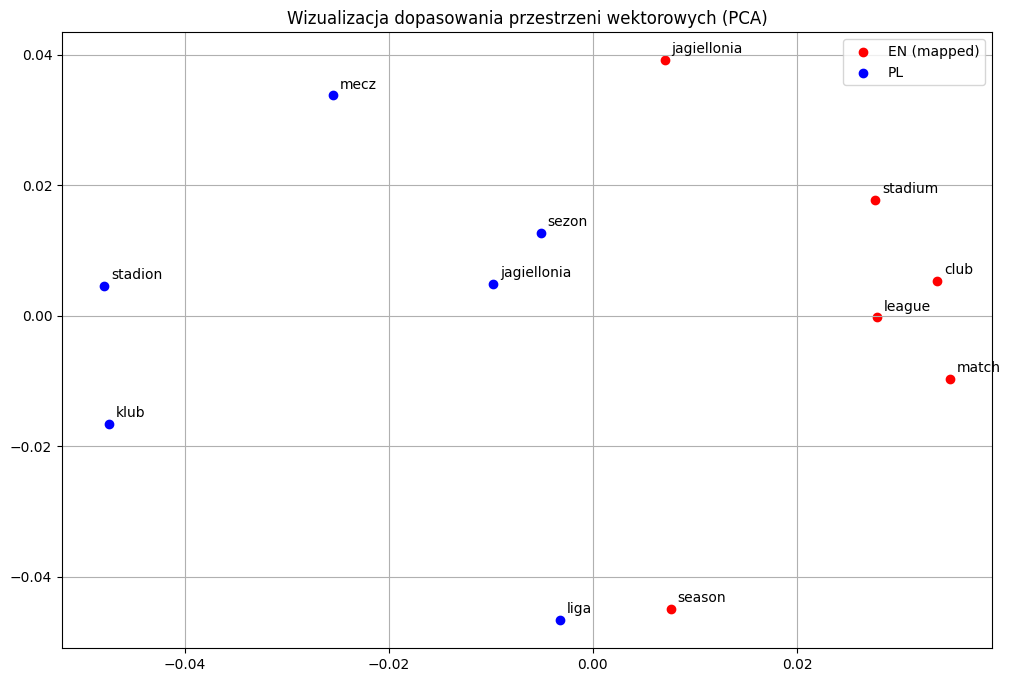

In [54]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_alignment(words_en, words_pl):
    vecs_en = [w2v_model_en.wv[w] @ W for w in words_en] 
    vecs_pl = [w2v_model_pl.wv[w] for w in words_pl]
    
    all_vecs = np.array(vecs_en + vecs_pl)
    
    pca = PCA(n_components=2)
    coords = pca.fit_transform(all_vecs)
    
    plt.figure(figsize=(12, 8))
    
    plt.scatter(coords[:len(words_en), 0], coords[:len(words_en), 1], c='red', label='EN (mapped)')
    for i, txt in enumerate(words_en):
        plt.annotate(txt, (coords[i, 0], coords[i, 1]), xytext=(5,5), textcoords='offset points')
        
    plt.scatter(coords[len(words_en):, 0], coords[len(words_en):, 1], c='blue', label='PL')
    for i, txt in enumerate(words_pl):
        plt.annotate(txt, (coords[len(words_en)+i, 0], coords[len(words_en)+i, 1]), xytext=(5,5), textcoords='offset points')
    
    plt.title("Wizualizacja dopasowania przestrzeni wektorowych (PCA)")
    plt.legend()
    plt.grid(True)
    plt.show()

words_to_plot = ["jagiellonia", "club", "league", "match", "stadium", "season"]
plot_alignment(words_to_plot, ["jagiellonia", "klub", "liga", "mecz", "stadion", "sezon"])

In [62]:
try:
    result = w2v_model_pl.wv.most_similar(positive=['jagiellonia', 'mistrz'], negative=['klub'], topn=3)
    print("Wynik (Jagiellonia - Klub + mistrz):")
    for word, score in result:
        print(f" - {word}: {score:.4f}")
except Exception as e:
    print("Błąd: Słowa nie ma w słowniku.")

Wynik (Jagiellonia - Klub + mistrz):
 - okazać: 0.3638
 - mistrzostwo: 0.3157
 - ówczesny: 0.2844


In [78]:
try:
    result = w2v_model_pl.wv.most_similar(positive=['jagiellonia', 'klub'], topn=3)
    print("Wynik (Jagiellonia + klub):")
    for word, score in result:
        print(f" - {word}: {score:.4f}")
except Exception as e:
    print("Błąd: Słowa nie ma w słowniku.")

Wynik (Jagiellonia + klub):
 - białystok: 0.7643
 - pierwszy: 0.7611
 - rok: 0.7476
